📊 生成 000063.SZ 的可视化图表...


C:\Users\Admin\AppData\Local\Temp\ipykernel_19416\1270343496.py:544: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
c:\Users\Admin\anaconda3\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


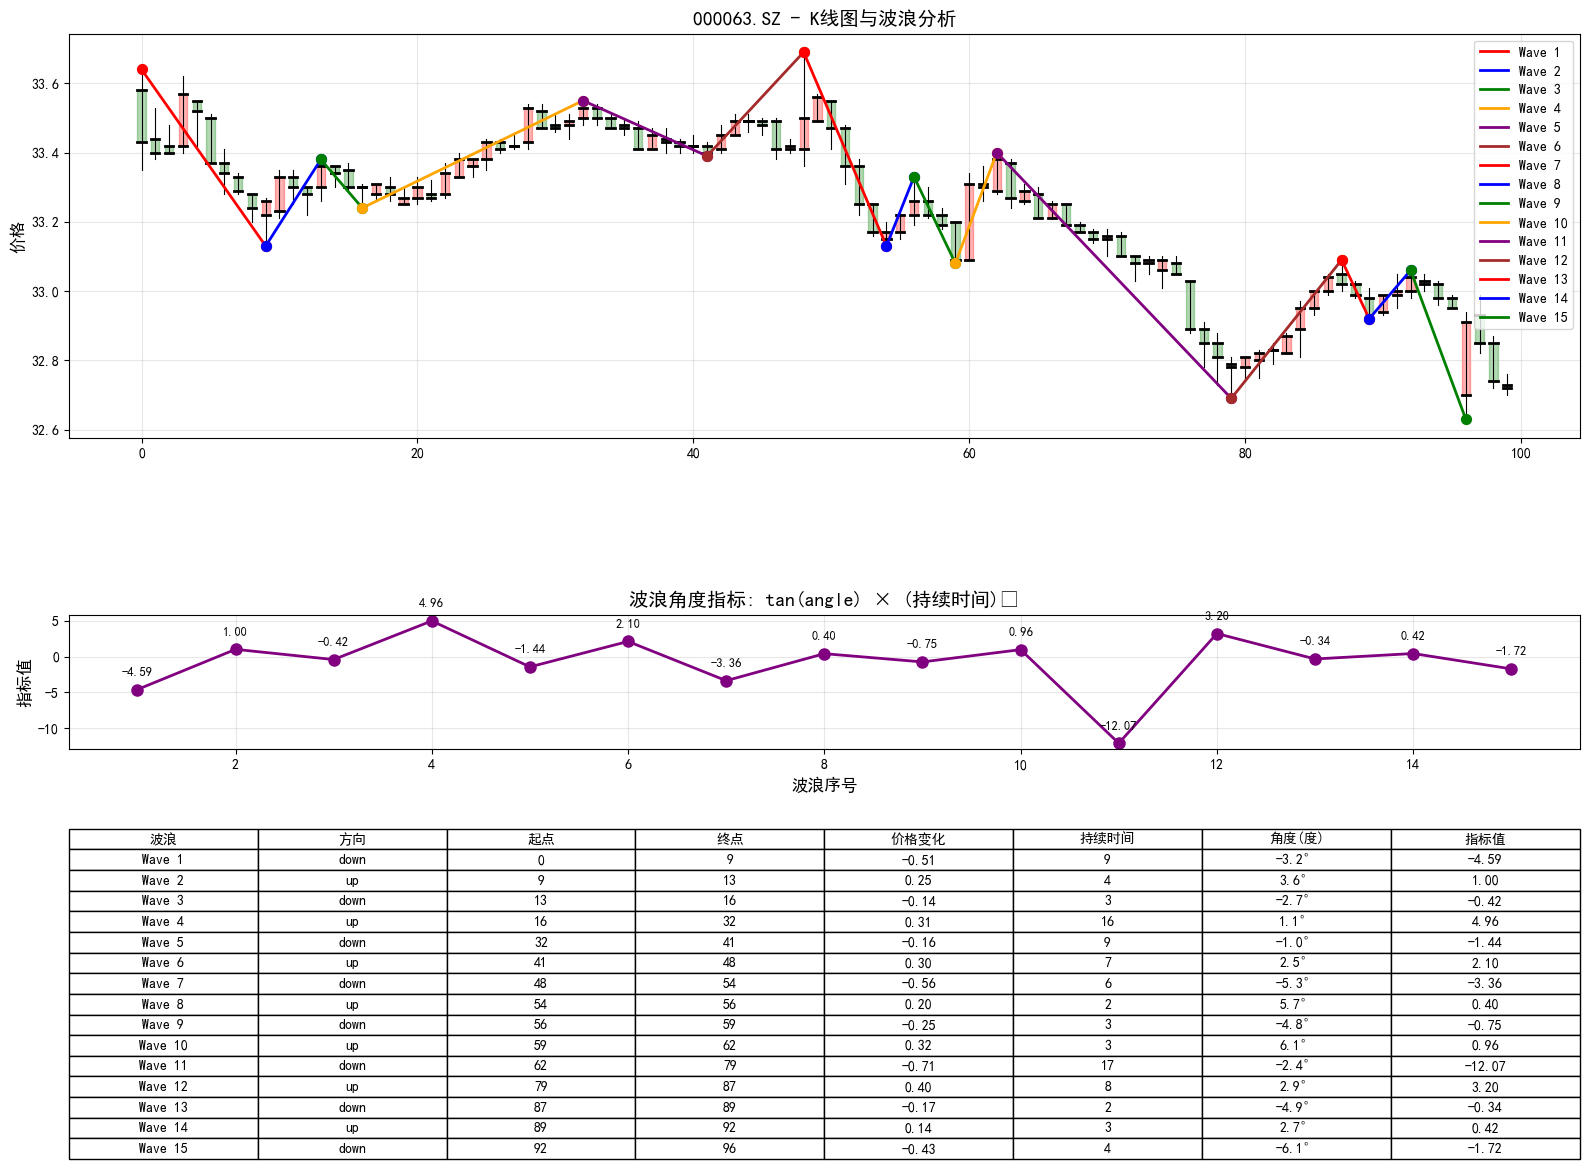


📈 000063.SZ 波浪分析统计:
   波浪数量: 15
   指标范围: -12.07 ~ 4.96
   平均指标: -0.78
   上升波浪: 7个, 平均指标: 1.86
   下降波浪: 8个, 平均指标: -3.09


In [5]:
import pandas as pd
import numpy as np
import math
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# 设置中文字体
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
# ========== 保持你原有的所有函数不变 ==========
def detect_high_low_points(df, window=3):
    """可靠检测高点和低点极点"""
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    if len(df) > 0:
        if len(high_prices) > 0 and high_prices[0] >= max(high_prices[:min(3, len(high_prices))]):
            if 0 not in high_indices:
                high_indices = np.insert(high_indices, 0, 0)
        if len(low_prices) > 0 and low_prices[0] <= min(low_prices[:min(3, len(low_prices))]):
            if 0 not in low_indices:
                low_indices = np.insert(low_indices, 0, 0)
        if len(high_prices) > 0 and high_prices[-1] >= max(high_prices[-min(3, len(high_prices)):]):
            if len(high_prices)-1 not in high_indices:
                high_indices = np.append(high_indices, len(high_prices)-1)
        if len(low_prices) > 0 and low_prices[-1] <= min(low_prices[-min(3, len(low_prices)):]):
            if len(low_prices)-1 not in low_indices:
                low_indices = np.append(low_indices, len(low_prices)-1)
    
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    df.iloc[high_indices, df.columns.get_loc('is_high')] = True
    df.iloc[low_indices, df.columns.get_loc('is_low')] = True
    
    if len(high_indices) >= 3:
        for i in range(1, len(high_indices) - 1):
            prev_idx = high_indices[i-1]
            current_idx = high_indices[i]
            next_idx = high_indices[i+1]
            current_high = high_prices[current_idx]
            prev_high = high_prices[prev_idx]
            next_high = high_prices[next_idx]
            if current_high > prev_high and current_high > next_high:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_high')] = True
    
    if len(low_indices) >= 3:
        for i in range(1, len(low_indices) - 1):
            prev_idx = low_indices[i-1]
            current_idx = low_indices[i]
            next_idx = low_indices[i+1]
            current_low = low_prices[current_idx]
            prev_low = low_prices[prev_idx]
            next_low = low_prices[next_idx]
            if current_low < prev_low and current_low < next_low:
                df.iloc[current_idx, df.columns.get_loc('is_extreme_low')] = True
    
    return df

def mark_extremes_in_merged_points(merged_points, df):
    """在合并后的点序列中补全极值"""
    if len(merged_points) == 0:
        return

    if 'is_extreme_high' not in df.columns:
        df['is_extreme_high'] = False
    if 'is_extreme_low' not in df.columns:
        df['is_extreme_low'] = False

    i = 0
    n = len(merged_points)
    
    while i < n:
        curr_type = merged_points[i][1]
        segment = []
        j = i
        
        while j < n and merged_points[j][1] == curr_type:
            segment.append(merged_points[j])
            j += 1
        
        has_extreme = False
        for idx, pt_type, price in segment:
            if pt_type == 'high':
                if df.iloc[idx]['is_extreme_high']:
                    has_extreme = True
                    break
            else:
                if df.iloc[idx]['is_extreme_low']:
                    has_extreme = True
                    break
        
        if not has_extreme and len(segment) >= 2:
            if curr_type == 'high':
                max_pt = max(segment, key=lambda x: x[2])
                df.iloc[max_pt[0], df.columns.get_loc('is_extreme_high')] = True
            else:
                min_pt = min(segment, key=lambda x: x[2])
                df.iloc[min_pt[0], df.columns.get_loc('is_extreme_low')] = True
        
        i = j

def merge_nearby_points(points, centers, price_range, merge_threshold=0.05):
    """合并中枢附近的高低点"""
    if not points or not centers:
        return points
    
    merge_distance = price_range * merge_threshold
    merged_points = []
    i = 0
    
    while i < len(points):
        current_point = points[i]
        current_idx, current_type, current_price = current_point
        
        near_center = False
        for center in centers:
            if abs(current_price - center) <= merge_distance:
                near_center = True
                break
        
        if near_center:
            group = [current_point]
            j = i + 1
            
            while j < len(points):
                next_point = points[j]
                next_idx, next_type, next_price = next_point
                
                next_near_center = False
                for center in centers:
                    if abs(next_price - center) <= merge_distance:
                        next_near_center = True
                        break
                
                if next_near_center and next_type == current_type:
                    group.append(next_point)
                    j += 1
                else:
                    break
            
            if len(group) > 1:
                merged_points.append(group[0])
                merged_points.append(group[-1])
            else:
                merged_points.append(current_point)
            
            i = j
        else:
            merged_points.append(current_point)
            i += 1
    
    return merged_points

def simple_connect_points(points, df_with_high_low):
    """波浪连接逻辑"""
    if len(points) < 2:
        return []

    waves = []
    i = 0
    n = len(points)

    while i < n:
        curr_idx, curr_type, curr_price = points[i]
        target_type = 'low' if curr_type == 'high' else 'high'

        j = i + 1
        while j < n and points[j][1] != target_type:
            j += 1
        
        if j >= n:
            break

        segment_start = j
        while j < n and points[j][1] == target_type:
            j += 1
        segment_end = j
        target_segment = points[segment_start:segment_end]

        target_point = None
        for pt in target_segment:
            pt_idx, pt_type, pt_price = pt
            is_extreme = False
            if pt_type == 'high':
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_high']
            else:
                is_extreme = df_with_high_low.iloc[pt_idx]['is_extreme_low']
            
            if is_extreme:
                target_point = pt
                break
        
        if target_point is None:
            target_point = target_segment[-1]

        if curr_type == 'low':
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'low',
                'end_type': 'high',
                'direction': 'up',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': target_point[2] - curr_price
            }
        else:
            wave = {
                'start_idx': curr_idx,
                'end_idx': target_point[0],
                'start_type': 'high',
                'end_type': 'low',
                'direction': 'down',
                'start_price': curr_price,
                'end_price': target_point[2],
                'height': curr_price - target_point[2]
            }
        waves.append(wave)

        next_i = segment_start
        while next_i < segment_end and points[next_i] != target_point:
            next_i += 1
        
        if next_i >= segment_end:
            next_i = segment_end - 1

        i = next_i

    return waves

def identify_waves_from_points(points, df_with_high_low):
    """从高低点序列识别波浪"""
    if len(points) < 2:
        return []
    
    waves = simple_connect_points(points, df_with_high_low)
    
    for i, wave in enumerate(waves):
        wave['wave_number'] = i + 1
    
    return waves

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        volumes = df['volume'].values
        closes = df['close'].values
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        return volume_points
    
    def cluster_prices(self, points, n_clusters=6):
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 6)
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        center_zones.sort(key=lambda x: x[0])
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        non_overlapping_zones.sort(key=lambda x: x[0])
        return non_overlapping_zones

def plot_kline_with_waves_and_angle_metric(df, waves, angle_metric_values, stock_name):
    """
    绘制包含K线、波浪线段和角度指标的三合一图表
    """
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1])
    
    # 第一个子图：K线图和波浪线段
    ax1 = plt.subplot(gs[0])
    
    # 绘制K线（简化版，用高低收盘线）
    for i in range(len(df)):
        open_price = df.iloc[i]['open']
        high_price = df.iloc[i]['high']
        low_price = df.iloc[i]['low']
        close_price = df.iloc[i]['close']
        
        # 绘制上下影线
        ax1.plot([i, i], [low_price, high_price], 'k-', linewidth=0.8)
        
        # 绘制实体
        if close_price >= open_price:
            # 阳线
            ax1.plot([i-0.3, i+0.3], [open_price, open_price], 'k-', linewidth=2)
            ax1.plot([i-0.3, i+0.3], [close_price, close_price], 'k-', linewidth=2)
            ax1.fill_between([i-0.3, i+0.3], open_price, close_price, 
                           color='red', alpha=0.3)
        else:
            # 阴线
            ax1.plot([i-0.3, i+0.3], [open_price, open_price], 'k-', linewidth=2)
            ax1.plot([i-0.3, i+0.3], [close_price, close_price], 'k-', linewidth=2)
            ax1.fill_between([i-0.3, i+0.3], open_price, close_price, 
                           color='green', alpha=0.3)
    
    # 绘制波浪线段
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    for i, wave in enumerate(waves):
        color = colors[i % len(colors)]
        start_idx = wave['start_idx']
        end_idx = wave['end_idx']
        start_price = wave['start_price']
        end_price = wave['end_price']
        
        # 绘制线段
        ax1.plot([start_idx, end_idx], [start_price, end_price], 
                color=color, linewidth=2, label=f'Wave {i+1}')
        
        # 标记起点和终点
        ax1.scatter(start_idx, start_price, color=color, s=50, zorder=5)
        ax1.scatter(end_idx, end_price, color=color, s=50, zorder=5)
    
    ax1.set_title(f'{stock_name} - K线图与波浪分析', fontsize=14, fontweight='bold')
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 第二个子图：角度指标 tan(angle) * (time_duration)^2
    ax2 = plt.subplot(gs[1])
    
    # 计算每个波浪的指标值
    wave_numbers = []
    metric_values = []
    
    for i, wave in enumerate(waves):
        angle_radians = wave['angle_radians']
        time_duration = wave['time_duration']
        
        # 计算指标：tan(angle) * (time_duration)^2
        metric_value = math.tan(angle_radians) * (time_duration ** 2)
        
        wave_numbers.append(i + 1)
        metric_values.append(metric_value)
    
    # 绘制指标点线图
    ax2.plot(wave_numbers, metric_values, 'o-', color='purple', linewidth=2, markersize=8)
    ax2.set_title('波浪角度指标: tan(angle) × (持续时间)²', fontsize=14, fontweight='bold')
    ax2.set_ylabel('指标值', fontsize=12)
    ax2.set_xlabel('波浪序号', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 在点上标注数值
    for i, (wave_num, value) in enumerate(zip(wave_numbers, metric_values)):
        ax2.annotate(f'{value:.2f}', (wave_num, value), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    
    # 第三个子图：详细的波浪信息表格
    ax3 = plt.subplot(gs[2])
    ax3.axis('tight')
    ax3.axis('off')
    
    # 准备表格数据
    table_data = []
    headers = ['波浪', '方向', '起点', '终点', '价格变化', '持续时间', '角度(度)', '指标值']
    
    for i, wave in enumerate(waves):
        angle_degrees = math.degrees(wave['angle_radians'])
        metric_value = metric_values[i]
        
        row = [
            f'Wave {i+1}',
            wave['direction'],
            f"{wave['start_idx']}",
            f"{wave['end_idx']}",
            f"{wave['price_change']:.2f}",
            f"{wave['time_duration']}",
            f"{angle_degrees:.1f}°",
            f"{metric_value:.2f}"
        ]
        table_data.append(row)
    
    # 创建表格
    table = ax3.table(cellText=table_data, colLabels=headers, 
                     loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    plt.tight_layout()
    plt.show()
    
    return metric_values

# ========== 核心函数：分析并可视化波浪角度指标 ==========
def analyze_and_plot_wave_angles(csv_path):
    """
    从CSV文件分析波浪角度并生成可视化图表
    计算 tan(angle) * (time_duration)^2 指标
    """
    # 读取数据
    df = pd.read_csv(csv_path, index_col='trade_date', parse_dates=['trade_date'], nrows=100)
    df = df.sort_index()
    
    if len(df) == 0:
        print(f"文件 {csv_path} 无数据")
        return
    
    df = df.reset_index(drop=True)
    stock_name = Path(csv_path).stem.replace('_analysis', '')
    
    # 1. 先找中枢
    analyzer = KLineCenterAnalyzer()
    center_lines, reversal_points, volume_points = analyzer.find_centers(df)
    center_zones = analyzer.calculate_center_zones(df, center_lines)
    
    # 2. 再找高低点
    df_with_high_low = detect_high_low_points(df)
    
    # 获取所有高低点
    high_points = [(idx, 'high', df.iloc[idx]['high']) for idx in df_with_high_low[df_with_high_low['is_high']].index]
    low_points = [(idx, 'low', df.iloc[idx]['low']) for idx in df_with_high_low[df_with_high_low['is_low']].index]
    
    # 合并高低点并按索引排序
    all_points = sorted(high_points + low_points, key=lambda x: x[0])
    
    # 3. 合并中枢附近的高低点
    price_range = df['high'].max() - df['low'].min()
    merged_points = merge_nearby_points(all_points, center_lines, price_range)
    
    # 新增：在合并后的点序列中补全极值
    mark_extremes_in_merged_points(merged_points, df_with_high_low)
    
    # 4. 从合并后的点识别波浪
    waves = identify_waves_from_points(merged_points, df_with_high_low)
    
    if not waves:
        print(f"文件 {csv_path} 未生成有效波浪")
        return
    
    # 5. 计算每个波浪的角度和指标
    angle_metric_values = []
    
    for wave in waves:
        start_idx = wave['start_idx']
        end_idx = wave['end_idx']
        start_price = wave['start_price']
        end_price = wave['end_price']
        direction = wave['direction']
        height_abs = wave['height']
        
        time_duration = end_idx - start_idx
        if time_duration <= 0:
            time_duration = 1
        
        price_change = end_price - start_price
        angle_radians = math.atan2(price_change, time_duration)
        
        # 计算指标：tan(angle) * (time_duration)^2
        metric_value = math.tan(angle_radians) * (time_duration ** 2)
        
        # 添加到波浪数据中
        wave['angle_radians'] = angle_radians
        wave['price_change'] = price_change
        wave['time_duration'] = time_duration
        wave['metric_value'] = metric_value
        
        angle_metric_values.append(metric_value)
    
    # 6. 生成可视化图表
    print(f"📊 生成 {stock_name} 的可视化图表...")
    metric_values = plot_kline_with_waves_and_angle_metric(df, waves, angle_metric_values, stock_name)
    
    # 7. 打印统计信息
    print(f"\n📈 {stock_name} 波浪分析统计:")
    print(f"   波浪数量: {len(waves)}")
    print(f"   指标范围: {min(metric_values):.2f} ~ {max(metric_values):.2f}")
    print(f"   平均指标: {np.mean(metric_values):.2f}")
    
    # 按方向分类统计
    up_waves = [w for w in waves if w['direction'] == 'up']
    down_waves = [w for w in waves if w['direction'] == 'down']
    
    if up_waves:
        up_metrics = [w['metric_value'] for w in up_waves]
        print(f"   上升波浪: {len(up_waves)}个, 平均指标: {np.mean(up_metrics):.2f}")
    
    if down_waves:
        down_metrics = [w['metric_value'] for w in down_waves]
        print(f"   下降波浪: {len(down_waves)}个, 平均指标: {np.mean(down_metrics):.2f}")
    
    return waves, metric_values

# ========== 使用示例 ==========
if __name__ == "__main__":
    # 处理单个文件
    csv_file = r'E:\stock\backtest\data\analyzed\5min\000063.SZ_analysis.csv'
    waves, metrics = analyze_and_plot_wave_angles(csv_file)
    
    # 批量处理示例（可选）
    """
    input_dir = r"E:\stock\csv_version\analysis_results"
    for csv_path in Path(input_dir).glob("*_analysis.csv"):
        try:
            analyze_and_plot_wave_angles(csv_path)
        except Exception as e:
            print(f"处理文件 {csv_path} 时出错: {e}")
    """